In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import glob

In [3]:
root = r"D:\EMTEQ\stari\FEIT_eating_S05"
subjects = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

In [4]:
subjects

['Andrej Petrov',
 'Andrej Trajkoski',
 'Angela Nastovska',
 'Bojan Dimovski',
 'Bojan Radovski',
 'Damjan Srebrenkoski',
 'Daniela Kovachovska',
 'Filip Sivevski',
 'Gorica Kovachovska',
 'Ilina Kovachovska',
 'Iva Jovanova',
 'Ivana Kiprijanovska',
 'Jovana Kostadinovska',
 'Kristijan Milosheski',
 'Marija Kovachovska',
 'Marko Kostov',
 'Matej Zlatkov',
 'Monika Stoilkovska',
 'Nikola Dimovski',
 'Ognen Sekuloski',
 'Sandra Shandarovska',
 'Sara Ilievska',
 'Sara Kovachovska',
 'Sashko Kovachovski',
 'Stefan Dinushev',
 'Stefanija Lazarovska',
 'Tarek Abd El-Azis',
 'Teodora Domazetovikj',
 'Tomi Jovanov',
 'Tomi Nikoloski',
 'Vasko Dimitrovski',
 'Vedrana Petreska',
 'Vladimir Petrov']

In [5]:
len(subjects)

33

In [6]:
subject_csv = {}

for s in subjects:
    subj_dir = os.path.join(root, s)
    csvs = glob.glob(os.path.join(subj_dir, "eating_processed.csv"))

    if len(csvs) == 0:
        print(f" NO eating_processed for {s}")
    elif len(csvs) > 1:
        print(f" MORE than one for {s}, using first")
        subject_csv[s] = csvs[0]
    else:
        subject_csv[s] = csvs[0]

print("Total subjects with eating_processed:", len(subject_csv))

 NO eating_processed for Andrej Trajkoski
Total subjects with eating_processed: 32


In [7]:
def load_subject_df(subject):
    csv_path = subject_csv[subject]
    df = pd.read_csv(csv_path)
    df["subject"] = subject
    return df

In [ ]:
import hashlib

def stable_hash_split(subjects, train_ratio=0.50, val_ratio=0.20):
    # train = [0, train_ratio)
    # val   = [train_ratio, train_ratio + val_ratio)
    # test  = ostatok
    def score(name):
        h = hashlib.md5(name.encode("utf-8")).hexdigest()
        return int(h[:8], 16) / 0xFFFFFFFF

    train, val, test = [], [], []
    for s in subjects:
        r = score(s)
        if r < train_ratio:
            train.append(s)
        elif r < train_ratio + val_ratio:
            val.append(s)
        else:
            test.append(s)
    return train, val, test


subjects = sorted(subjects)

train_subjects, val_subjects, test_subjects = stable_hash_split(
    subjects,
    train_ratio=0.50,
    val_ratio=0.20
)

print("NOVI TRAIN:", len(train_subjects), train_subjects)
print("NOVI VAL:",   len(val_subjects), val_subjects)
print("NOVI TEST:",  len(test_subjects), test_subjects)


NOVI TRAIN: 21 ['Andrej Petrov', 'Bojan Radovski', 'Damjan Srebrenkoski', 'Daniela Kovachovska', 'Gorica Kovachovska', 'Ilina Kovachovska', 'Iva Jovanova', 'Ivana Kiprijanovska', 'Jovana Kostadinovska', 'Kristijan Milosheski', 'Marko Kostov', 'Monika Stoilkovska', 'Ognen Sekuloski', 'Sara Ilievska', 'Sashko Kovachovski', 'Stefan Dinushev', 'Stefanija Lazarovska', 'Teodora Domazetovikj', 'Tomi Jovanov', 'Vasko Dimitrovski', 'Vladimir Petrov']
NOVI VAL: 6 ['Matej Zlatkov', 'Nikola Dimovski', 'Sandra Shandarovska', 'Sara Kovachovska', 'Tarek Abd El-Azis', 'Tomi Nikoloski']
NOVI TEST: 6 ['Andrej Trajkoski', 'Angela Nastovska', 'Bojan Dimovski', 'Filip Sivevski', 'Marija Kovachovska', 'Vedrana Petreska']


In [9]:
train_dfs = [load_subject_df(s) for s in train_subjects if s in subject_csv]
val_dfs   = [load_subject_df(s) for s in val_subjects   if s in subject_csv]
test_dfs  = [load_subject_df(s) for s in test_subjects  if s in subject_csv]

print(len(train_dfs), len(val_dfs), len(test_dfs))

21 6 5


In [10]:
cols_to_drop = [
    "SoftwareTimestamp",
    "Timestamp",
    "Accelerometer/Raw.Z",
    "Gyroscope/Raw.Z",
    "Magnetometer/Raw.X",
    "Magnetometer/Raw.Y",
    "Magnetometer/Raw.Z",
    "Nav/Shutter[LeftTemple]",
    "Nav/FrameAvg[LeftTemple]",
    "Pressure/Raw", 
    "RotationVector/Raw.W",
    "RotationVector/Raw.Z",
]

train_dfs = [df.drop(columns=cols_to_drop, errors="ignore") for df in train_dfs]
val_dfs   = [df.drop(columns=cols_to_drop, errors="ignore") for df in val_dfs]
test_dfs  = [df.drop(columns=cols_to_drop, errors="ignore") for df in test_dfs]

In [11]:
train_df = pd.concat(train_dfs, ignore_index=True)
val_df   = pd.concat(val_dfs,   ignore_index=True)
test_df  = pd.concat(test_dfs,  ignore_index=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(650844, 12) (147791, 12) (197230, 12)
21 6 5


In [12]:
def make_windows_from_dfs(
    dfs,#po eden covek
    label_col,
    feature_cols=None,
    window_samples=150,#kolku samples
    step_samples=25,#cekor mejgu prozorci
    label_strategy="majority"
):
    X_list, y_list = [], []
#loop niz site dataframes
    for df in dfs:
        # земи feature колони
        if feature_cols is None:
            num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            feature_cols = [c for c in num_cols if c != label_col]

        X_raw = df[feature_cols].to_numpy(dtype=np.float32)
        y_raw = df[label_col].to_numpy()

        n = len(X_raw)
        if n < window_samples:
            continue
#sliding window loop 
        for start in range(0, n - window_samples + 1, step_samples):
            end = start + window_samples
            #eden input priemrok za mdoelot
            Xw = X_raw[start:end]
#label za prozorecot
            y_seg = y_raw[start:end]
            if label_strategy == "last":
                yw = y_seg[-1]
            else:
                vals, counts = np.unique(y_seg, return_counts=True)
                yw = vals[np.argmax(counts)]

            X_list.append(Xw)
            y_list.append(yw)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)
    return X, y

In [ ]:
label_col   = "Annotations"
subject_col = "subject"
time_col    = "SoftwareTimestamp"  

exclude = {label_col, subject_col, "SoftwareTimestamp", "Timestamp"}
feature_cols = [c for c in train_df.columns if c not in exclude]

print("n_features =", len(feature_cols))
print("first features:", feature_cols[:10])


n_features = 10
first features: ['Accelerometer/Raw.X', 'Accelerometer/Raw.Y', 'Gyroscope/Raw.X', 'Gyroscope/Raw.Y', 'RotationVector/Raw.X', 'RotationVector/Raw.Y', 'Nav/Raw.X[LeftTemple]', 'Nav/Raw.Y[LeftTemple]', 'Prox/Raw[LeftTemple]', 'Nav/IQ[LeftTemple]']


In [14]:
LABEL_COL = "Annotations"
#kolku vreme vo sekundi opfajka eden prozorec
WINDOW_SEC = 4.0
#kolku sekundi da se pomesti sleden prozorec
STEP_SEC   = 0.5
#50 sampli vo 1 sekunda
WINDOW_SAMPLES = int(round(WINDOW_SEC * 50))
STEP_SAMPLES   = int(round(STEP_SEC * 50))

print("Window samples:", WINDOW_SAMPLES, "| Step samples:", STEP_SAMPLES)

Window samples: 200 | Step samples: 25


In [15]:
X_train, y_train = make_windows_from_dfs(train_dfs, label_col=LABEL_COL,feature_cols=feature_cols,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_val, y_val     = make_windows_from_dfs(val_dfs,   label_col=LABEL_COL,feature_cols=feature_cols,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_test, y_test   = make_windows_from_dfs(test_dfs,  label_col=LABEL_COL,feature_cols=feature_cols,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)

print(X_train.shape, X_val.shape, X_test.shape)
print("labels:", np.unique(y_train))

(25877, 200, 10) (5867, 200, 10) (7852, 200, 10)
labels: [0 1]


In [16]:
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (25877, 200, 10) (25877,)
Val:   (5867, 200, 10) (5867,)
Test:  (7852, 200, 10) (7852,)


In [17]:
mean = X_train.mean(axis=(0,1), keepdims=True)
std  = X_train.std(axis=(0,1), keepdims=True)
std[std == 0] = 1

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print("train mean first 5 feats:", X_train.mean(axis=(0,1))[:5])
print("train std  first 5 feats:", X_train.std(axis=(0,1))[:5])

train mean first 5 feats: [-1.2520641e-03 -1.0626501e-01  1.3189069e-06 -4.9114300e-07
 -5.5212029e-03]
train std  first 5 feats: [0.9990724  0.99492675 0.9999057  1.0003216  1.0009621 ]


In [18]:
print(train_df.columns.tolist())


['Accelerometer/Raw.X', 'Accelerometer/Raw.Y', 'Gyroscope/Raw.X', 'Gyroscope/Raw.Y', 'RotationVector/Raw.X', 'RotationVector/Raw.Y', 'Nav/Raw.X[LeftTemple]', 'Nav/Raw.Y[LeftTemple]', 'Prox/Raw[LeftTemple]', 'Nav/IQ[LeftTemple]', 'Annotations', 'subject']


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (200, 12)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv1D(64, 7, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.2),

    layers.Conv1D(128, 5, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.2),

    layers.Conv1D(256, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,497 (634.75 KB)

 Trainable params: 161,601 (631.25 KB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
from sklearn.utils.class_weight import compute_class_weight

In [22]:
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
class_weight # dali klasite se ramnomerni

{0: 1.631794677765166, 1: 0.7208881212391353}

In [23]:
cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                     patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                         factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    #class_weight=class_weight,  # ako sakash go dodavame tuka
    callbacks=cb,
    verbose=1
)

Epoch 1/60
102/102 ━━━━━━━━━━━━━━━━━━━━ 65s 469ms/step - accuracy: 0.8460 - auc: 0.9048 - loss: 0.3498 - precision: 0.8673 - recall: 0.9185 - val_accuracy: 0.7050 - val_auc: 0.8634 - val_loss: 0.5369 - val_precision: 0.9180 - val_recall: 0.4783 - learning_rate: 0.0010
Epoch 2/60
102/102 ━━━━━━━━━━━━━━━━━━━━ 77s 420ms/step - accuracy: 0.9005 - auc: 0.9497 - loss: 0.2521 - precision: 0.9125 - recall: 0.9474 - val_accuracy: 0.7915 - val_auc: 0.8907 - val_loss: 0.4357 - val_precision: 0.7657 - val_recall: 0.8663 - learning_rate: 0.0010
Epoch 3/60
102/102 ━━━━━━━━━━━━━━━━━━━━ 45s 441ms/step - accuracy: 0.9088 - auc: 0.9566 - loss: 0.2325 - precision: 0.9180 - recall: 0.9538 - val_accuracy: 0.8101 - val_auc: 0.9052 - val_loss: 0.4634 - val_precision: 0.7706 - val_recall: 0.9067 - learning_rate: 0.0010
Epoch 4/60
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 410ms/step - accuracy: 0.9122 - auc: 0.9592 - loss: 0.2258 - precision: 0.9185 - recall: 0.9584 - val_accuracy: 0.8043 - val_auc: 0.9044 - val_loss: 

In [24]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.492).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_test, y_pred, digits=4))

246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step
Confusion matrix:
 [[2242  896]
 [ 427 4287]]
              precision    recall  f1-score   support

           0     0.8400    0.7145    0.7722      3138
           1     0.8271    0.9094    0.8663      4714

    accuracy                         0.8315      7852
   macro avg     0.8336    0.8119    0.8192      7852
weighted avg     0.8323    0.8315    0.8287      7852



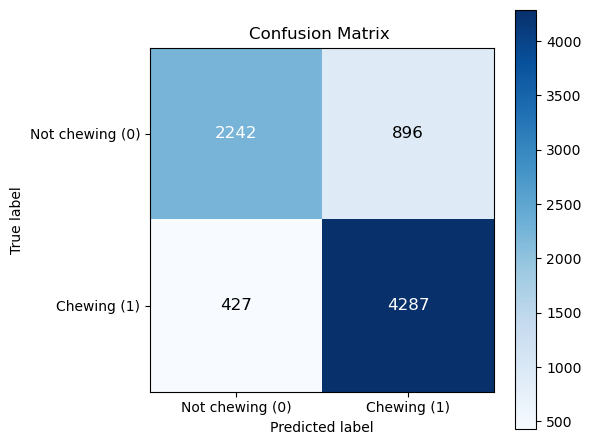

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix ")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

classes = ["Not chewing (0)", "Chewing (1)"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [29]:
#izbor na najdobar treshold
fpr, tpr, thr = roc_curve(y_test, y_prob)
best = thr[(tpr - fpr).argmax()]
print(best)

0.6287777


In [30]:
model.save("base_old_model.keras")
np.savez(
    "base_old_scaler.npz",
    mean=mean,
    std=std
)

## new podatoci

In [31]:
root = r"D:\EMTEQ\novi"
new_subjects = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

In [32]:
new_subject_csv = {}

for s in new_subjects:
    subj_dir = os.path.join(root, s)
    csvs = glob.glob(os.path.join(subj_dir, "*_eating_processed.csv"))

    if len(csvs) == 0:
        print(f" NO eating_processed for {s}")
    elif len(csvs) > 1:
        print(f" MORE than one for {s}, using first")
        new_subject_csv[s] = csvs[0]
    else:
        new_subject_csv[s] = csvs[0]

print("Total subjects with eating_processed:", len(new_subject_csv))

 NO eating_processed for BorjanP
 NO eating_processed for HristijanT
 NO eating_processed for PetarP
Total subjects with eating_processed: 39


In [33]:
new_subjects

['AleksandraK',
 'AnaI',
 'AndrejCh',
 'AndrejJ',
 'AngelaK',
 'AngelaN',
 'BojanD',
 'BorjanP',
 'DavidN',
 'ElenaA',
 'HristijanD',
 'HristijanT',
 'IrinaP',
 'IvaI',
 'IvanP',
 'KristinaK',
 'LeoJ',
 'MarijaB',
 'MartinD',
 'MatrinI',
 'MihaelaD',
 'MilaP',
 'MonikaS',
 'PavelT',
 'PetarP',
 'RezeartaLj',
 'RistoK',
 'Sandra',
 'SandraM',
 'SandraSh',
 'SaraI',
 'SaraSh',
 'SlavicaSh',
 'StefanI',
 'StefanijaK',
 'StefanIl',
 'StojanV',
 'Teodora',
 'TeodoraD',
 'TeodorS',
 'TomiN',
 'VladimirK']

In [38]:
#fiksni lujge birame 
train_subjects = [
    "RistoK", "StojanV", "AndrejJ", "IvaI", "IrinaP",
    "SaraSh", "StefanI", "StefanijaK",
    "RezeartaLj", "PavelT", "IvanP",
    "AngelaK", "HristijanD","SlavicaSh","SandraM",
    "TeodorS","MilaP","MartinD","StefanIl", "DavidN"
]

val_subjects = [
    "AleksandraK", "KristinaK",
    "MihaelaD","VladimirK", "AndrejCh"
]

test_subjects = [
    "ElenaA", "LeoJ", "MarijaB",
    "MatrinI", "AnaI"
]

print("TRAIN:", len(train_subjects), train_subjects)
print("VAL:",   len(val_subjects), val_subjects)
print("TEST:",  len(test_subjects), test_subjects)


TRAIN: 20 ['RistoK', 'StojanV', 'AndrejJ', 'IvaI', 'IrinaP', 'SaraSh', 'StefanI', 'StefanijaK', 'RezeartaLj', 'PavelT', 'IvanP', 'AngelaK', 'HristijanD', 'SlavicaSh', 'SandraM', 'TeodorS', 'MilaP', 'MartinD', 'StefanIl', 'DavidN']
VAL: 5 ['AleksandraK', 'KristinaK', 'MihaelaD', 'VladimirK', 'AndrejCh']
TEST: 5 ['ElenaA', 'LeoJ', 'MarijaB', 'MatrinI', 'AnaI']


In [39]:
def load_subject_df_new(subject):
    csv_path = new_subject_csv[subject]
    df = pd.read_csv(csv_path)
    df["subject"] = subject
    return df

In [40]:
train_dfs = [load_subject_df_new(s) for s in train_subjects if s in new_subject_csv]
val_dfs   = [load_subject_df_new(s) for s in val_subjects   if s in new_subject_csv]
test_dfs  = [load_subject_df_new(s) for s in test_subjects  if s in new_subject_csv]

print(len(train_dfs), len(val_dfs), len(test_dfs))

20 5 5


In [41]:
train_df = pd.concat(train_dfs, ignore_index=True)
val_df   = pd.concat(val_dfs,   ignore_index=True)
test_df  = pd.concat(test_dfs,  ignore_index=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(611946, 24) (156004, 24) (153006, 24)
20 5 5


In [42]:
cols_to_drop = [
    "Accelerometer Z",
    "Gyroscope Z",
    "Rotation Vector Z",
    "Rotation Vector W",
    "Magnetometer X",
    "Magnetometer Y",
    "Magnetometer Z",
    "Pressure",
    "Software Timestamp",   
    "Hardware Timestamp", 
    "Navigation Right Temple Frame Avg",
    "Navigation Right Temple Shutter",
]

train_df = train_df.drop(columns=cols_to_drop, errors="ignore")
val_df   = val_df.drop(columns=cols_to_drop, errors="ignore")
test_df  = test_df.drop(columns=cols_to_drop, errors="ignore")

In [43]:
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(611946, 12) (156004, 12) (153006, 12)
20 5 5


In [44]:
LABEL_COL = "Annotations"
SUBJECT_COL = "subject"

exclude = {LABEL_COL, SUBJECT_COL}
feature_cols_new = [c for c in train_df.columns if c not in exclude]

print("n_features_new =", len(feature_cols_new))
print(feature_cols_new)

n_features_new = 10
['Accelerometer X', 'Accelerometer Y', 'Gyroscope X', 'Gyroscope Y', 'Rotation Vector X', 'Rotation Vector Y', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Navigation Right Temple IQ']


In [45]:
fs = 50
WINDOW_SAMPLES = int(fs * 4.0)    # 200
STEP_SAMPLES   = int(fs * 0.5)    # 25

X_train_new, y_train_new = make_windows_from_dfs(train_dfs, label_col=LABEL_COL,feature_cols=feature_cols_new,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_val_new, y_val_new     = make_windows_from_dfs(val_dfs,   label_col=LABEL_COL,feature_cols=feature_cols_new,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_test_new, y_test_new   = make_windows_from_dfs(test_dfs,  label_col=LABEL_COL,feature_cols=feature_cols_new,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)

print("New shapes:", X_train_new.shape, X_val_new.shape, X_test_new.shape)
print("labels train:", np.unique(y_train_new, return_counts=True))


New shapes: (24330, 200, 10) (6204, 200, 10) (6085, 200, 10)
labels train: (array([0, 1]), array([ 9590, 14740]))


In [46]:
sc = np.load("base_old_scaler.npz")

In [47]:
mean = sc["mean"]
std  = sc["std"]

print("mean shape:", mean.shape, "std shape:", std.shape)
print("new features:", X_train_new.shape[-1])

mean shape: (1, 1, 10) std shape: (1, 1, 10)
new features: 10


In [48]:
X_train_new_z = (X_train_new - mean) / std
X_val_new_z   = (X_val_new   - mean) / std
X_test_new_z  = (X_test_new  - mean) / std


In [49]:
from tensorflow.keras.models import load_model

In [50]:
model = load_model("base_old_model.keras")
print("model input:", model.input_shape)

model input: (None, 200, 10)


In [51]:
#ova samo razlicno
for layer in model.layers:
    layer.trainable = True



In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

history_new = model.fit(
    X_train_new_z, y_train_new,
    validation_data=(X_val_new_z, y_val_new),
    epochs=10,          
    batch_size=256,
    verbose=1
)
#so se slucuva vsusnost pri full fine tune 
#se vcituva stariot model i tezinite se tie sto se nauceni na starite podatoic
#site sloevi pocnuvaaat da se menuvaat so fine tune taka sto modelot se premestuva kako raspredelba na novite lujge
#starite podatoci samo davaat kako nekoj voved vo karakteristikite so gi uci modelot potoa se doucuva na novite

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 279ms/step - accuracy: 0.7672 - auc: 0.8447 - loss: 0.6317 - val_accuracy: 0.8200 - val_auc: 0.9395 - val_loss: 0.3622
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 258ms/step - accuracy: 0.7915 - auc: 0.8632 - loss: 0.5249 - val_accuracy: 0.8773 - val_auc: 0.9595 - val_loss: 0.3107
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 272ms/step - accuracy: 0.8047 - auc: 0.8743 - loss: 0.4702 - val_accuracy: 0.8923 - val_auc: 0.9583 - val_loss: 0.3073
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 269ms/step - accuracy: 0.8139 - auc: 0.8793 - loss: 0.4462 - val_accuracy: 0.8968 - val_auc: 0.9594 - val_loss: 0.3030
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 251ms/step - accuracy: 0.8219 - auc: 0.8910 - loss: 0.4139 - val_accuracy: 0.9031 - val_auc: 0.9603 - val_loss: 0.2988
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 248ms/step - accuracy: 0.8330 - auc: 0.9006 - loss: 0.3923 - val_accuracy: 0.8975 - val_auc: 0.9574 - val_loss: 0.3046
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━

In [53]:
from sklearn.metrics import confusion_matrix, classification_report

# default threshold 0.5 (можеме да оптимизираме подоцна)
y_prob = model.predict(X_test_new_z).ravel()
y_pred = (y_prob >= 0.7).astype(int)

cm = confusion_matrix(y_test_new, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_test_new, y_pred, digits=4))

191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Confusion matrix:
 [[2753  127]
 [ 877 2328]]
              precision    recall  f1-score   support

           0     0.7584    0.9559    0.8458      2880
           1     0.9483    0.7264    0.8226      3205

    accuracy                         0.8350      6085
   macro avg     0.8533    0.8411    0.8342      6085
weighted avg     0.8584    0.8350    0.8336      6085



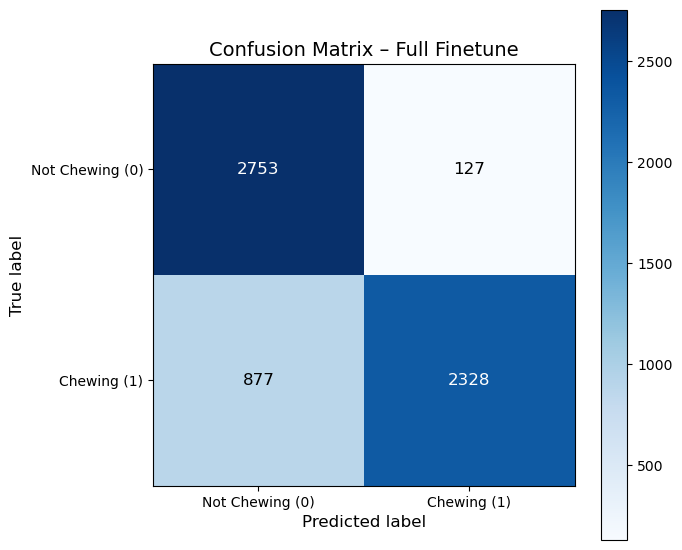

In [56]:
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([
    [2753, 127],
    [877, 2328]
])

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix – Full Finetune", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

classes = ["Not Chewing (0)", "Chewing (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thr = roc_curve(y_test_new, y_prob)
best = thr[(tpr - fpr).argmax()]
print(best)


0.4486534


In [ ]:
import os 

In [ ]:
save_dir = r"D:\EMTEQ\modeli"

np.savez(
    os.path.join(save_dir, "base_old_scaler.npz"),
    mean=mean,
    std=std
)

print("Saved scaler to:", save_dir)

Saved scaler to: C:\emteq proekt


-Proverka da vidime dali so full finetune dali zaboravil info za starite podatoci

In [ ]:

from tensorflow.keras.models import load_model
#go vcituvame stariot model

base_model = load_model("base_old_model.keras")


In [ ]:
import numpy as np
#vcituvame star scaler
sc = np.load("base_old_scaler.npz")
mean = sc["mean"]
std  = sc["std"]


In [ ]:
#star test skaliran kako pri trening
X_test_z = (X_test - mean) / std


In [ ]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import load_model

base_model = load_model("base_old_model.keras")
#performans na star model
#vrajka verojatnost(0-1)
y_prob_old = base_model.predict(X_test_z).ravel()
#meri klk dobro modelot gi razdeluva 0 i 1 , bez da se bira treshold
auc_old = roc_auc_score(y_test, y_prob_old)

print("BASELINE AUC (old test):", auc_old)



170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
BASELINE AUC (old test): 0.5683516285797758


In [ ]:
baseline_metrics = {
    "auc_old_test": auc_old
}

np.save("baseline_metrics.npy", baseline_metrics)


In [ ]:
X_test_z = (X_test - mean) / std
#modelot gi ima nauceni tezinite vo ovaa skala zatoa mora da se skalira


In [ ]:
#ova e za full finetuned model 
y_prob_ft_old = model.predict(X_test_z).ravel()
auc_ft_old = roc_auc_score(y_test, y_prob_ft_old)
#presmetuva vrednots i razlika 
print("FINETUNED AUC (old test):", auc_ft_old)
print("Δ AUC:", auc_ft_old - auc_old)


170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
FINETUNED AUC (old test): 0.5838787169456381
Δ AUC: 0.015527088365862252


-ova random biranje mislam ne e ok poso sekoj run za auc mi davat mn razlicni vrednosti preska za aud posle full fine tune mi dade 0.73.., sega 0.58

AUC (Area Under ROC Curve) значи:

Ако земеш еден случај што е eating (1) и еден што не е (0),
моделот ќе му даде поголема веројатност на вистинскиот eating во ~74% од паровите.